# Simulazione d'esame Laboratorio di Programmazione 2

## Esercizio 1

1. Crea un vettore NumPy con i seguenti **canoni mensili d'affitto** (in euro) per 4 appartamenti: **720, 980, 650, 1200**

2. Calcola la **spesa totale mensile** sostenuta dagli inquilini.

3. Il proprietario dell'appartamento da **1200 €** decide di **aumentare l’affitto del 12%**.
    - Modifica il vettore per applicare l’aumento.
    - L’importo aggiornato deve essere esattamente **1344,00 €**, controlla se appare **esattamente** nel tuo array.


4. L'inquilino dell'appartamento da **650 €** ottiene uno **sconto del 10%**.
    - Applica la modifica.

5. Gli altri due appartamenti (**720 € e 980 €**) subiscono un **aumento del 5%**.
    - Aggiorna il vettore di conseguenza.

7. Calcola la **nuova spesa totale mensile** dopo tutti i cambiamenti.

8. Infine: quanto ha influito **l’aumento dell’affitto più alto** sulla spesa complessiva?

    (Suggerimento: confronta la spesa totale **prima di qualsiasi modifica** e **dopo il solo aumento del canone a 1200 €**.)


In [22]:
import numpy as np

# 1. Vettore iniziale
affitti = np.array ([720, 980, 650, 1200])
print ("PUNTO 1:")
print ("- Affitti originali:", affitti.tolist())

# 2. Spesa totale iniziale
totale_iniziale = affitti.sum()
print ("\nPUNTO 2:")
print (f"- Spesa totale mensile iniziale: {totale_iniziale:.2f} €")


# 3. Aumento del 12% sull'appartamento d 1200 €
affitti_modificati = affitti.copy()
affitti_modificati[3] *= 1.12
print ("\nPUNTO 3:")
print ("- Dopo aumento 12% sul 1200:" , affitti_modificati.tolist())
controllo = affitti_modificati[3]
print (f"- Nuovo affitto (1200+12%): {controllo:.2f} € -> esattamente 1344? {controllo == 1344.00}")


# 4. Sconto del 10% sull'appartamento da 650 €
affitti_modificati[2] *= 0.9
print ("\nPUNTO 4:")
print ("- Dopo sconto 10 % sul 650:", affitti_modificati.tolist())


# 5. Aumento del 5 % sui restanti (720 e 980)
affitti_modificati[0] *= 1.05
affitti_modificati[1] *= 1.05
print ("\nPUNTO 5:")
print ("- Dopo aumento del 5% su 720 e 980", affitti_modificati.tolist())


# 6. Nuova spesa totale mensile
totale_nuovo = affitti_modificati.sum()
print ("\nPUNTO 6:")
print (f"- Nuova spesa totale mensile: {totale_nuovo:.2f} €")


# 7 Impatto del solo aumento sul 1200
solo_aumento_1200 = affitti.copy()
solo_aumento_1200[3] *= 1.12
totale_solo_1200 = solo_aumento_1200.sum()
influenza = totale_solo_1200 - totale_iniziale
print ("\nPUNTO 7:")
print (f"- Influenza del solo aumento sul 1200: +{influenza:.2f} €")


PUNTO 1:
- Affitti originali: [720, 980, 650, 1200]

PUNTO 2:
- Spesa totale mensile iniziale: 3550.00 €

PUNTO 3:
- Dopo aumento 12% sul 1200: [720, 980, 650, 1344]
- Nuovo affitto (1200+12%): 1344.00 € -> esattamente 1344? True

PUNTO 4:
- Dopo sconto 10 % sul 650: [720, 980, 585, 1344]

PUNTO 5:
- Dopo aumento del 5% su 720 e 980 [756, 1029, 585, 1344]

PUNTO 6:
- Nuova spesa totale mensile: 3714.00 €

PUNTO 7:
- Influenza del solo aumento sul 1200: +144.00 €


## Esercizio 2

Consideriamo un semplice processo di random walk (cammino aleatorio) in una dimensione:
a ogni passo temporale, un camminatore si sposta a destra (+1) o a sinistra (-1) con uguale probabilità. Supponiamo che il camminatore parta sempre da x=0.

1. Scrivi una funzione che simula il cammino per n passi ed N camminatori e restituisce due array. Il primo rappresenta la media della posizione ad ogni passo degli N camminatori ed il secondo la deviazione standard della posizione ad ogni passo degli N camminatori.

2. Fai prima il plot della media delle posizione degli N camminatori per 100 passi 

3. Fai il plot con anche la devizione standard.  La deviazione standard diminuisce all'aumentare del campione? Che andamento ha la deviazione standard rispeto l tempo/passi?

PUNTO 1:
- Funzione definita
- Media posizione dopo 100 passi = 1.7000

PUNTO 2 - Plot della media:


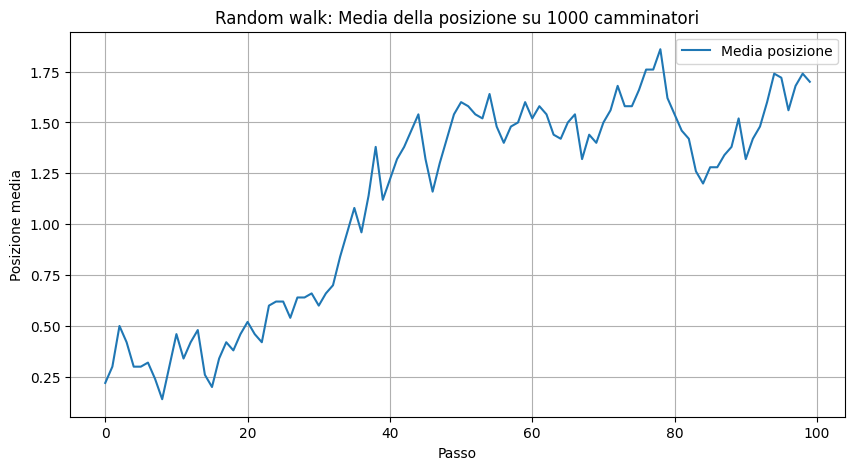


PUNTO 3 - Plot della deviazione standard:


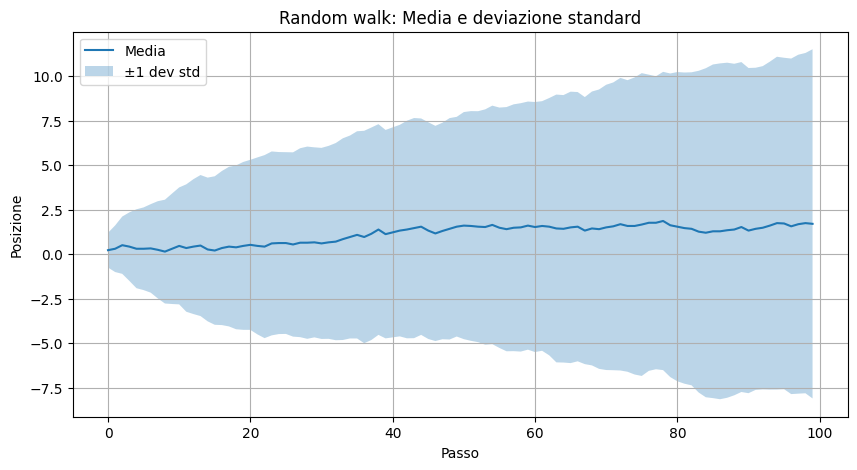


PUNTO 4 - Domande:
1: La deviazione standard cresce circa come la radice quadrata del numero di passi.
2: All'aumentare del campione (N), la stima della dev std diventa più precisa, ma il suo valore teorico non dipende da N.


In [49]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed (0)

# 1. Funzione che simula n passi per N camminatori
def random_walk_sim(n, N):
    steps = np.random.choice ([-1, 1], size = (N, n))     # steps: +1 o -1 con uguale probabilità
    positions = np.cumsum (steps, axis = 1)               # posizioni cumulative (somma lungo i passi)
    mean_pos = np.mean(positions, axis=0)                 # media per ogni passo (colonna)                 
    std_pos = np.std(positions, axis=0)                   # dev standard per ogni passo
    return mean_pos, std_pos

print ("PUNTO 1:")
print ("- Funzione definita")

# Simulazione per n = 100 passi, N = 1000 camminatori
n_passi = 100
N_camminatori = 100
mean_pos, std_pos = random_walk_sim(n_passi, N_camminatori)
print(f"- Media posizione dopo {n_passi} passi = {mean_pos[-1]:.4f}")


# 2. Plot della media
print ("\nPUNTO 2 - Plot della media:")
plt.figure(figsize=(10,5))
plt.plot(range(n_passi), mean_pos, label='Media posizione')
plt.xlabel('Passo')
plt.ylabel('Posizione media')
plt.title('Random walk: Media della posizione su 1000 camminatori')
plt.legend()
plt.grid()
plt.show()


# 3. Plot della deviazione standard
print ("\nPUNTO 3 - Plot della deviazione standard:")
plt.figure(figsize=(10,5))
plt.plot(range(n_passi), mean_pos, label='Media')
plt.fill_between(range(n_passi), mean_pos - std_pos, mean_pos + std_pos, alpha=0.3, label='±1 dev std')
plt.xlabel('Passo')
plt.ylabel('Posizione')
plt.title('Random walk: Media e deviazione standard')
plt.legend()
plt.grid()
plt.show()


print ("\nPUNTO 4 - Domande:")
print("1: La deviazione standard cresce circa come la radice quadrata del numero di passi.")
print("2: All'aumentare del campione (N), la stima della dev std diventa più precisa, ma il suo valore teorico non dipende da N.")



## Esercizio 3

Genera un array `a` di dimensioni **5 x 9** contenente numeri da una distribuzione gaussiana con media 0 e dev standard 1.  
Per ogni riga, seleziona il numero **più vicino a 0.1**.
Imposta il seed per la riproducibilità `np.random.seed(42)`

 *Suggerimento*: per ottenere `a[i, j]`, l'array `i` deve contenere gli **indici di riga** corrispondenti agli elementi in `j`.


In [54]:
import numpy as np

# 1. Genero la matrice 5x9 gaussiana (media = 0, std = 1)
np.random.seed (0)
a = np.random.normal (0, 1, (5, 9))
print ("PUNTO 1: Matrice generata (5x9)")
print (a, "\n")


# 2. Per ogni riga, trovo il valore più vicino a 0.1
valori_vicini = []
for i in range(5):
    riga = a[i]
    distanze = np.abs(riga - 0.1)
    indice_min = np.argmin(distanze)
    valore = riga[indice_min]
    valori_vicini.append (float(valore))

print ("\nPUNTO 2: Valore più vicino a 0.1 per ogni riga:")
print([round(v, 4) for v in valori_vicini])

PUNTO 1: Matrice generata (5x9)
[[ 1.76405235  0.40015721  0.97873798  2.2408932   1.86755799 -0.97727788
   0.95008842 -0.15135721 -0.10321885]
 [ 0.4105985   0.14404357  1.45427351  0.76103773  0.12167502  0.44386323
   0.33367433  1.49407907 -0.20515826]
 [ 0.3130677  -0.85409574 -2.55298982  0.6536186   0.8644362  -0.74216502
   2.26975462 -1.45436567  0.04575852]
 [-0.18718385  1.53277921  1.46935877  0.15494743  0.37816252 -0.88778575
  -1.98079647 -0.34791215  0.15634897]
 [ 1.23029068  1.20237985 -0.38732682 -0.30230275 -1.04855297 -1.42001794
  -1.70627019  1.9507754  -0.50965218]] 


PUNTO 2: Valore più vicino a 0.1 per ogni riga:
[-0.1032, 0.1217, 0.0458, 0.1549, -0.3023]


## Esercizio 4

Utilizza il dataset `titanic`, disponibile all'url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

Esegui un’analisi esplorativa sui dati dei passeggeri, focalizzandoti su tariffe, età e componenti familiari.

1. **Visualizza i primi 10 passeggeri ordinati per tariffa pagata** (`Fare`), dal più alto al più basso.

2. **Calcola la media** di:
   - `Age` (età)
   - `Fare` (tariffa)
   - `SibSp` (numero di fratelli/coniugi a bordo)

3. **Crea una nuova colonna** chiamata `Family_index`, definita come:

   $$
   \texttt{family\_index} = \frac{\texttt{sibsp} + \texttt{parch}}{\texttt{fare}}
   $$

   *(Indicatore del “peso familiare” per unità di spesa – attenzione a eventuali divisioni per zero!)*

4. Trova il **passeggero con il valore massimo** di `Family_index`.

5. **Filtra solo i passeggeri** che hanno pagato **più di 100** di tariffa (`Fare > 100`).

6. **Crea un grafico a barre** con i 10 passeggeri che hanno pagato di più (`Fare`).

7. **Crea un grafico a linee** dell’età (`Age`), ordinando i passeggeri per tariffa (`Fare`) crescente.



💡 *Suggerimenti*:
- Ricordati di gestire eventuali valori mancanti in `Age` o `Fare` prima di fare operazioni.


## Esercizio 5

Usa il dataset `penguins`, disponibile tramite `seaborn.load_dataset("penguins")`.


1. Quante righe e colonne ha il dataset?

2. Controlla quanti valori mancanti ci sono per colonna.

3. Riempi i valori mancanti nella colonna `sex` con il valore più frequente.

4. Rimuovi le righe in cui il valore `body_mass_g` è mancante.

5. Controlla se ci sono righe duplicate.

6. Calcola la **massa corporea media** (`body_mass_g`) per ogni specie (`species`).
  Se ci sono valori mancanti in `body_mass_g`, riempili con la media della specie.

7. Visualizza la **distribuzione della massa corporea** (`body_mass_g`) per specie.

8.  Visualizza la **distribuzione della massa corporea** per specie, **dividendo per sesso** (`sex`) e mostrandoli a confronto.


💡 Suggerimento: usa `seaborn.violinplot()`, `boxplot()` o `kdeplot()` con `hue='sex'`.


PUNTO 1:
- Le dimensioni sono: Righe: 344, Colonne: 7

PUNTO 2 - I valori mancanti sono:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

PUNTO 3:
- Valori mancanti in 'sex' dopo riempimento: 0

PUNTO 4:
- Dimensioni dopo dropna su body_mass_g: (342, 7)

PUNTO 5:
- Righe duplicate: 0

PUNTO 6 - Massa corporea media per specie:
species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

PUNTO 7: Violin plot della massa corporea per specie


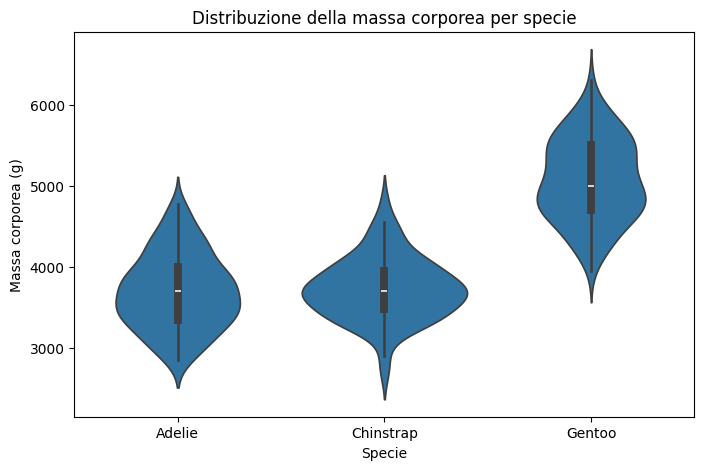


PUNTO 8: Violin plot per specie e sesso


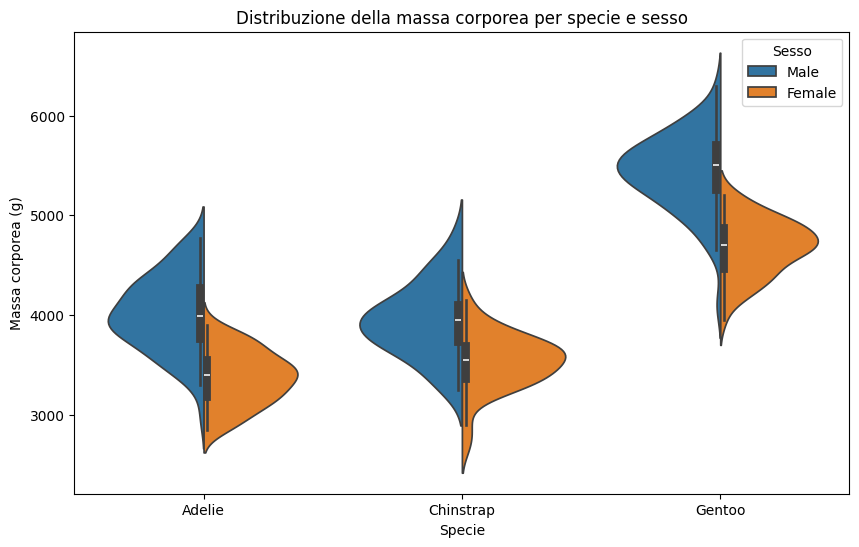

In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carico il dataset e verifico le dimensioni
df = sns.load_dataset("penguins")
print ("PUNTO 1:")
print (f"- Le dimensioni sono: Righe: {df.shape[0]}, Colonne: {df.shape[1]}")


# 2. Valori mancanti per colonna
print ("\nPUNTO 2 - I valori mancanti sono:")
print (df.isnull().sum())


# 3. Riempio i valori mancanti in 'sex' con la moda
moda_sex = df['sex'].mode()[0]
df['sex'] = df['sex'].fillna(moda_sex)
print ("\nPUNTO 3:")
print ("- Valori mancanti in 'sex' dopo riempimento:", df['sex'].isnull().sum())


# 4. Rimuovo righe con body_mass_g mancante
df = df.dropna(subset=['body_mass_g'])
print ("\nPUNTO 4:")
print ("- Dimensioni dopo dropna su body_mass_g:", df.shape)


# 5. Verifico righe duplicate

duplicati = df.duplicated().sum()
print ("\nPUNTO 5:")
print (f"- Righe duplicate: {duplicati}")


# 6. Massa corporea media per specie (riempio eventuali NaN con media della specie)
media_per_specie = df.groupby('species')['body_mass_g'].transform('mean')   # Calcolo media per specie
df['body_mass_g'] = df['body_mass_g'].fillna(media_per_specie)
media_specie = df.groupby('species')['body_mass_g'].mean()
print ("\nPUNTO 6 - Massa corporea media per specie:")
print (media_specie)


# 7. Distribuzione della massa corporea per specie (violin plot)
print("\nPUNTO 7: Violin plot della massa corporea per specie")
plt.figure(figsize=(8,5))
sns.violinplot(x='species', y='body_mass_g', data=df)
plt.xlabel ('Specie')
plt.ylabel ('Massa corporea (g)')
plt.title ('Distribuzione della massa corporea per specie')
plt.show()


# 8. Distribuzione per specie, divisa per sesso
print("\nPUNTO 8: Violin plot per specie e sesso")
plt.figure(figsize=(10,6))
sns.violinplot(x='species', y='body_mass_g', hue='sex', data=df, split=True)
plt.xlabel('Specie')
plt.ylabel('Massa corporea (g)')
plt.title('Distribuzione della massa corporea per specie e sesso')
plt.legend(title='Sesso')
plt.show()

## Esercizio 6

Hai due array NumPy generati come segue:

`x = np.linspace(0, 10, 100)`  
`y = 3 * x + 2 + np.random.normal(0, 1, 100)`

Scrivi una funzione `fit_line(x, y)` che:

- usa `scipy.optimize.curve_fit` per eseguire un **fitting lineare** del tipo `y = a * x + b`;  
- restituisce una tupla contenente:
  - i **parametri ottimizzati** `a` e `b`;  
  - una **stringa** che descrive la retta trovata, ad esempio: `"y = 3.02 * x + 1.95"`.


Esempio di output atteso:   (3.02, 1.95, "y = 3.02 * x + 1.95")

Fai un esempio di utilizzo dove poi plotti i dati e la curva ottenuta.


PUNTO 1: 
Parametri stimati: a = 2.9703, b = 2.2085

PUNTO 2 - Grafico


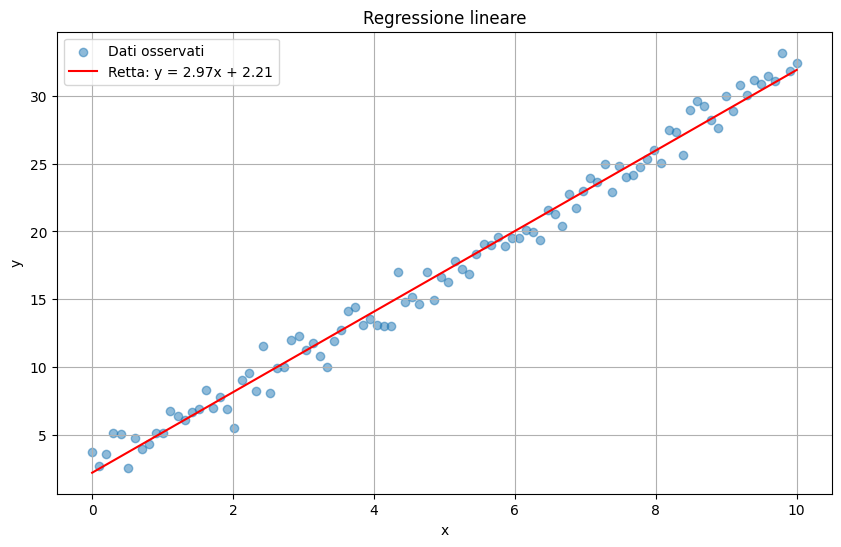


PUNTO 3: 
- MAE = 0.8051
- RMSE = 1.0041


In [106]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Creo i dati e stimo i parametri
np.random.seed(0)
x = np.linspace(0, 10, 100)
y = 3 * x + 2 + np.random.normal(0, 1, 100)    

def modello_lineare(x, a, b):
    return a * x + b

popt, __ = curve_fit(modello_lineare, x, y)
a, b = popt
print("PUNTO 1: ")
print(f"Parametri stimati: a = {a:.4f}, b = {b:.4f}")


# 2. Grafico punti e retta
print("\nPUNTO 2 - Grafico")
y_pred = modello_lineare(x, a, b)

plt.figure(figsize=(10,6))
plt.scatter(x, y, label='Dati osservati', alpha=0.5)
plt.plot(x, y_pred, 'r-', label=f'Retta: y = {a:.2f}x + {b:.2f}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressione lineare')
plt.legend()
plt.grid()
plt.show()


# 3.  MAE e RMSE
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
print("\nPUNTO 3: ")
print(f"- MAE = {mae:.4f}")
print(f"- RMSE = {rmse:.4f}")
